# Notebook 14：时间参数化与时间最优沿路径规划 (TOPP)

## 1. 定位
运动规划器输出几何路径 $\mathbf{q}(s)$。时间参数化回答"多快走"——找到 $s(t)$ 使路径在时间上满足所有速度/加速度约束且总时间最短。

## 2. 学习目标
- ⭐ 路径参数化 $s \in [0,1]$: $\mathbf{q}(t) = \mathbf{f}(s(t))$
- ⭐ 链式分解: $\ddot{\mathbf{q}} = \mathbf{f}'(s)\ddot{s} + \mathbf{f}''(s)\dot{s}^2$
- ⭐ 在 $(s, \dot{s})$ 相平面中理解 MVC 和可行域
- ⭐ TOPP 核心: 前向最大加速 + 后向最大减速
- 📖 TOPP-RA 和力矩约束

## 3. 链式分解 ⭐

给定路径 $\mathbf{q} = \mathbf{f}(s), s \in [0, 1]$:
$$\dot{\mathbf{q}} = \mathbf{f}'(s)\dot{s}$$
$$\ddot{\mathbf{q}} = \mathbf{f}'(s)\ddot{s} + \mathbf{f}''(s)\dot{s}^2$$

关节约束转化为对 $(s, \dot{s})$ 的约束:
$$-\dot{q}_{max,i} \leq f'_i(s)\dot{s} \leq \dot{q}_{max,i}$$
$$-\ddot{q}_{max,i} \leq f'_i(s)\ddot{s} + f''_i(s)\dot{s}^2 \leq \ddot{q}_{max,i}$$

## 4. TOPP 相平面算法 ⭐

### 4.1 MVC (Maximum Velocity Curve)
对每个 $s$，从关节速度约束求 $\dot{s}$ 上限:
$$\dot{s}_{max}(s) = \min_i \frac{\dot{q}_{max,i}}{|f'_i(s)|}$$
若 $f'_i(s) = 0$，该关节对 $\dot{s}$ 无约束。

### 4.2 加速度约束下的可行加速/减速
从 $\ddot{q}_{min} \leq f'\ddot{s} + f''\dot{s}^2 \leq \ddot{q}_{max}$:
$$\alpha_i(s, \dot{s}) = \begin{cases}
(\ddot{q}_{min,i} - f''_i\dot{s}^2)/f'_i & f'_i > 0 \\
(\ddot{q}_{max,i} - f''_i\dot{s}^2)/f'_i & f'_i < 0
\end{cases}$$
$$\beta_i(s, \dot{s}) = \begin{cases}
(\ddot{q}_{max,i} - f''_i\dot{s}^2)/f'_i & f'_i > 0 \\
(\ddot{q}_{min,i} - f''_i\dot{s}^2)/f'_i & f'_i < 0
\end{cases}$$
$$\alpha = \max_i \alpha_i, \quad \beta = \min_i \beta_i$$

### 4.3 前向 + 后向积分
1. 前向传播 (最大加速): 从 $(0, \dot{s}_0)$ 开始，用 $\beta(s, \dot{s})$ 加速
2. 后向传播 (最大减速): 从 $(1, \dot{s}_f)$ 开始，用 $\alpha(s, \dot{s})$ 减速
3. 下包络 = 时间最优 $\dot{s}(s)$
4. 使用 $\dot{s}_{k+1}^2 = \dot{s}_k^2 + 2\ddot{s}\Delta s$ (稳定递推)

## 5. Python 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')
from scipy.interpolate import CubicSpline
%matplotlib inline
rng = np.random.RandomState(42)
print("✅ 导入完成")

✅ 导入完成


### 5.1 一般路径 TOPP — 2R 臂样条路径

In [2]:
# 路径: 三次样条连接关节空间中的 via-points
via_pts = np.array([
    [0.0, 0.0],
    [0.5, -0.3],
    [1.2, 0.2],
    [0.8, 0.6],
    [1.5, 1.0],
])
s_grid = np.linspace(0, 1, len(via_pts))
cs1 = CubicSpline(s_grid, via_pts[:, 0], bc_type='natural')
cs2 = CubicSpline(s_grid, via_pts[:, 1], bc_type='natural')

n_s = 300
s_vals = np.linspace(0, 1, n_s)
ds = s_vals[1] - s_vals[0]

# f(s), f'(s), f''(s)
f_vals = np.column_stack([cs1(s_vals), cs2(s_vals)])
fp_vals = np.column_stack([cs1(s_vals, 1), cs2(s_vals, 1)])
fpp_vals = np.column_stack([cs1(s_vals, 2), cs2(s_vals, 2)])

# 关节约束
q_dot_max = np.array([3.0, 4.0])
q_ddot_max = np.array([8.0, 10.0])

# === MVC: 速度约束 ===
s_dot_mvc = np.full(n_s, np.inf)
for i in range(n_s):
    for d in range(2):
        if abs(fp_vals[i, d]) > 1e-10:
            s_dot_mvc[i] = min(s_dot_mvc[i], q_dot_max[d] / abs(fp_vals[i, d]))

# === 加速度约束 → α(s,ṡ), β(s,ṡ) ===
def compute_alpha_beta(s_idx, s_dot_val):
    """计算给定 (s, ṡ) 处的加速度约束 α ≤ s̈ ≤ β"""
    alpha = -np.inf; beta = np.inf
    for d in range(2):
        fp = fp_vals[s_idx, d]; fpp = fpp_vals[s_idx, d]
        term = fpp * s_dot_val**2
        if abs(fp) < 1e-10:
            # fp=0: 加速度约束退化为 |f''ṡ²| ≤ q̈_max
            if abs(term) > q_ddot_max[d]:
                alpha = max(alpha, 1e10); beta = min(beta, -1e10)  # 不可行
            continue
        lo = (-q_ddot_max[d] - term) / fp
        hi = (q_ddot_max[d] - term) / fp
        if fp > 0:
            alpha = max(alpha, lo); beta = min(beta, hi)
        else:
            alpha = max(alpha, hi); beta = min(beta, lo)
    return alpha, beta

# === 前向传播 (最大加速) ===
s_dot_fwd = np.zeros(n_s); s_dot_fwd[0] = 0.0
for i in range(1, n_s):
    _, beta = compute_alpha_beta(i-1, s_dot_fwd[i-1])
    # s_dot_{k+1}² = s_dot_k² + 2 * s̈ * Δs (稳定递推)
    # beta < 0 意味着必须减速 — 不能截断为0
    s_dot_sq = s_dot_fwd[i-1]**2 + 2 * beta * ds
    s_dot_fwd[i] = np.sqrt(max(0, s_dot_sq))
    s_dot_fwd[i] = min(s_dot_fwd[i], s_dot_mvc[i])

# === 后向传播 (最大减速) ===
s_dot_bwd = np.zeros(n_s); s_dot_bwd[-1] = 0.0
for i in range(n_s-2, -1, -1):
    alpha, _ = compute_alpha_beta(i+1, s_dot_bwd[i+1])
    # s_dot_k² = s_dot_{k+1}² - 2 * s̈ * Δs (向后积分)
    # alpha > 0 意味着加速度存在正下界 — 不能截断为0
    s_dot_sq = s_dot_bwd[i+1]**2 - 2 * alpha * ds
    s_dot_bwd[i] = np.sqrt(max(0, s_dot_sq))
    s_dot_bwd[i] = min(s_dot_bwd[i], s_dot_mvc[i])

# === 时间最优 = min(前向, 后向, MVC) ===
s_dot_opt = np.minimum(np.minimum(s_dot_fwd, s_dot_bwd), s_dot_mvc)

# === 从 ṡ(s) 计算 q(t) ===
t_path = np.zeros(n_s)
for i in range(1, n_s):
    s_dot_avg = max((s_dot_opt[i] + s_dot_opt[i-1]) / 2, 1e-6)
    t_path[i] = t_path[i-1] + ds / s_dot_avg

# 对比: 均匀时间参数化
s_dot_uniform = np.full(n_s, np.mean(s_dot_opt[s_dot_opt > 1e-3]))
t_uniform = np.zeros(n_s)
for i in range(1, n_s):
    t_uniform[i] = t_uniform[i-1] + ds / s_dot_uniform[i]

### 5.2 可视化

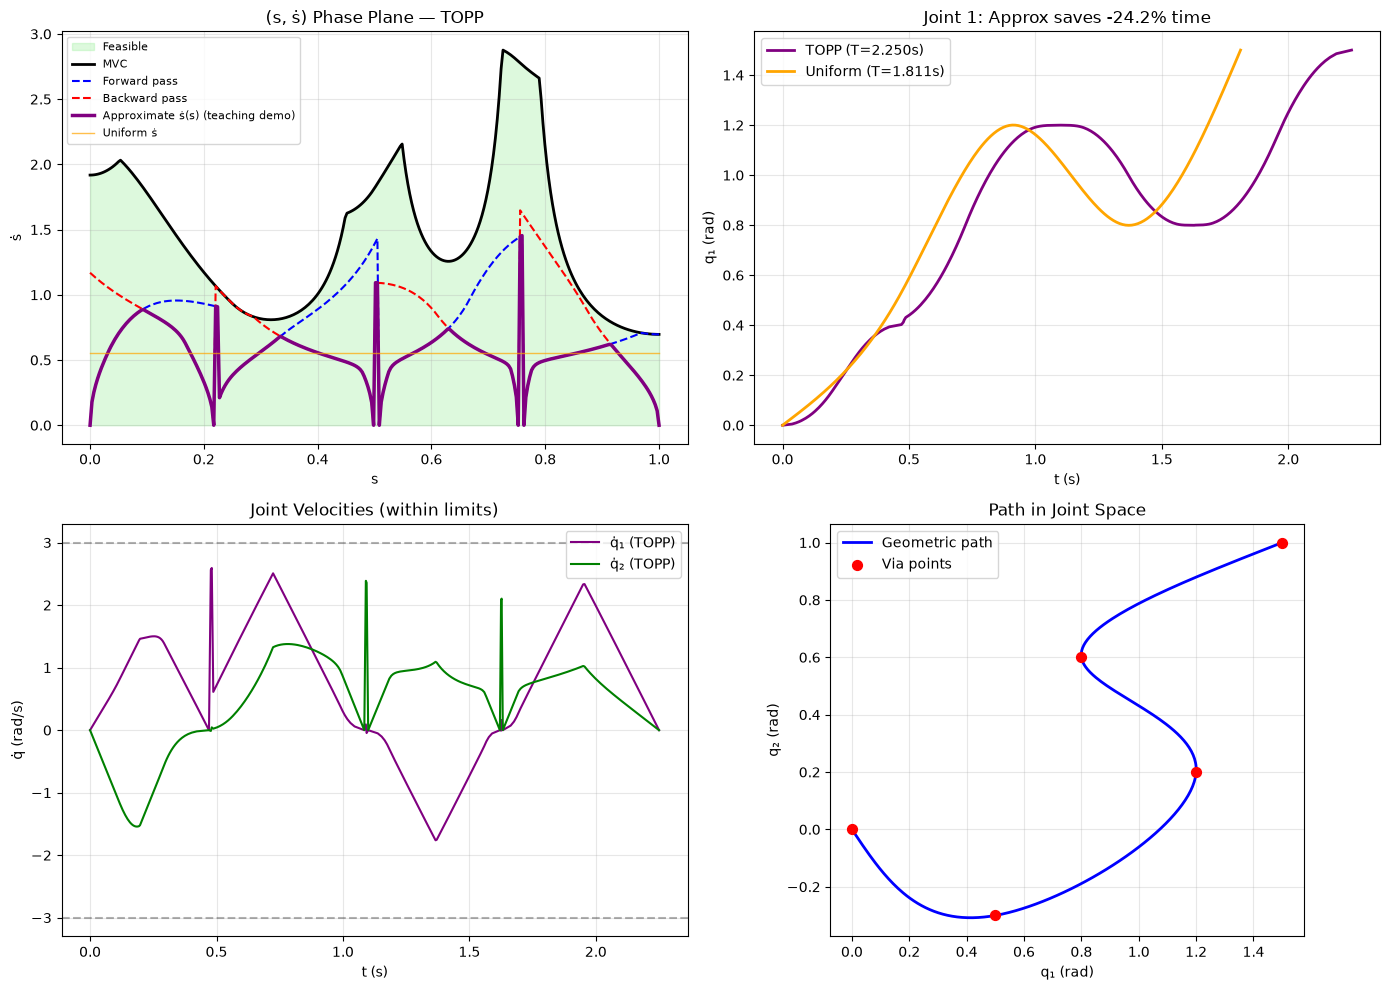

TOPP 总时间: 2.250s, 均匀: 1.811s, 节省: -24.2%
可行性: 速度 100% 满足, 加速度 74% 满足
⚠ 教学版前向-后向近似不能保证严格时间最优或全部约束满足。
  生产级 TOPP 请使用 TOPP-RA 或 toppra 库。


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (s, ṡ) 相平面
axes[0,0].fill_between(s_vals, 0, s_dot_mvc, color='lightgreen', alpha=0.3, label='Feasible')
axes[0,0].plot(s_vals, s_dot_mvc, 'k-', linewidth=2, label='MVC')
axes[0,0].plot(s_vals, s_dot_fwd, 'b--', linewidth=1.5, label='Forward pass')
axes[0,0].plot(s_vals, s_dot_bwd, 'r--', linewidth=1.5, label='Backward pass')
axes[0,0].plot(s_vals, s_dot_opt, 'purple', linewidth=2.5, label='Approximate ṡ(s) (teaching demo)')
axes[0,0].plot(s_vals, s_dot_uniform, 'orange', linewidth=1, alpha=0.7, label='Uniform ṡ')
axes[0,0].set_xlabel('s'); axes[0,0].set_ylabel('ṡ')
axes[0,0].set_title('(s, ṡ) Phase Plane — TOPP'); axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

# q₁(t) 对比
q_opt = np.column_stack([cs1(s_vals), cs2(s_vals)])
axes[0,1].plot(t_path, q_opt[:,0], 'purple', linewidth=2, label=f'TOPP (T={t_path[-1]:.3f}s)')
axes[0,1].plot(t_uniform, q_opt[:,0], 'orange', linewidth=2, label=f'Uniform (T={t_uniform[-1]:.3f}s)')
axes[0,1].set_xlabel('t (s)'); axes[0,1].set_ylabel('q₁ (rad)')
axes[0,1].set_title(f'Joint 1: Approx saves {(1-t_path[-1]/t_uniform[-1])*100:.1f}% time'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# 速度
q_dot_opt = fp_vals * s_dot_opt[:, None]  # q̇ = f'(s)ṡ
axes[1,0].plot(t_path, q_dot_opt[:,0], 'purple', linewidth=1.5, label='q̇₁ (TOPP)')
axes[1,0].plot(t_path, q_dot_opt[:,1], 'g-', linewidth=1.5, label='q̇₂ (TOPP)')
axes[1,0].axhline(y=q_dot_max[0], c='k', ls='--', alpha=0.3)
axes[1,0].axhline(y=-q_dot_max[0], c='k', ls='--', alpha=0.3)
axes[1,0].set_xlabel('t (s)'); axes[1,0].set_ylabel('q̇ (rad/s)')
axes[1,0].set_title('Joint Velocities (within limits)'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# 路径 q₁ vs q₂
axes[1,1].plot(q_opt[:,0], q_opt[:,1], 'b-', linewidth=2, label='Geometric path')
axes[1,1].scatter(via_pts[:,0], via_pts[:,1], c='red', s=50, zorder=5, label='Via points')
axes[1,1].set_xlabel('q₁ (rad)'); axes[1,1].set_ylabel('q₂ (rad)')
axes[1,1].set_title('Path in Joint Space'); axes[1,1].set_aspect('equal'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/14_topp_general_path.png', dpi=100, bbox_inches='tight')
plt.show()

# 可行性验证: 检查实际 q̇ = f'(s)ṡ, q̈ = f'(s)s̈ + f''(s)ṡ²
q_dot_actual = fp_vals * s_dot_opt[:, None]
# s̈ = dṡ/dt = ṡ · dṡ/ds (链式法则)
d_sdot_ds = np.gradient(s_dot_opt, ds)
s_ddot_actual = s_dot_opt * d_sdot_ds  # NOT ds alone!
q_ddot_actual = fp_vals * s_ddot_actual[:, None] + fpp_vals * s_dot_opt[:, None]**2
v_ok = np.all(np.abs(q_dot_actual) <= q_dot_max * 1.01, axis=1)
a_ok = np.all(np.abs(q_ddot_actual) <= q_ddot_max * 1.01, axis=1)
print(f"TOPP 总时间: {t_path[-1]:.3f}s, 均匀: {t_uniform[-1]:.3f}s, 节省: {(1-t_path[-1]/t_uniform[-1])*100:.1f}%")
print(f"可行性: 速度 {np.mean(v_ok)*100:.0f}% 满足, 加速度 {np.mean(a_ok)*100:.0f}% 满足")
print("⚠ 教学版前向-后向近似不能保证严格时间最优或全部约束满足。")
print("  生产级 TOPP 请使用 TOPP-RA 或 toppra 库。")

## 6. 练习题
1. MVC 曲线由什么约束决定？TOPP 如何保证不超出 MVC？
2. 为什么前向和后向积分都需要？只用前向会有什么问题？
3. 加入力矩约束后, $\alpha(s,\dot{s})$ 和 $\beta(s,\dot{s})$ 的新形式？

## 7. 本节总结
| 概念 | 公式 | 含义 |
|------|------|------|
| 链式分解 | $\ddot{\mathbf{q}} = \mathbf{f}'\ddot{s} + \mathbf{f}''\dot{s}^2$ | $\ddot{s}$ + $\dot{s}^2$ 分别贡献 |
| MVC | $\dot{s}_{max}(s) = \min_i \dot{q}_{max,i}/|f'_i(s)|$ | 速度硬上限 |
| 加速度约束 | $\alpha(s,\dot{s}) \leq \ddot{s} \leq \beta(s,\dot{s})$ | 从关节加速度反推 |
| 稳定递推 | $\dot{s}_{k+1}^2 = \dot{s}_k^2 + 2\ddot{s}\Delta s$ | 避免 $\dot{s} \approx 0$ 不稳定 |